# Illustration Exercise — LLM Agents

## Context

In Retrieval-Augmented Generation (RAG), a query is compared to a corpus of
document chunks using vector similarity. In this exercise the "corpus" consists
of recent news headlines for five financial firms, and the "query" is a natural
language risk question. TF-IDF cosine similarity ranks each chunk by relevance.
The bar chart visualises the ranked retrieval output that a real RAG system would
pass to the language model — making concrete the abstract notion of "retrieval".

## Data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
import yfinance as yf
import pathlib, warnings
warnings.filterwarnings("ignore")
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

plt.style.use(["science", "no-latex"])

tickers = ["AAPL", "MSFT", "JPM", "GS", "BAC"]
query = "What are the main risk factors and competitive threats facing the company?"

chunks, chunk_labels = [], []
for sym in tickers:
    news = yf.Ticker(sym).news or []
    for item in news[:3]:
        title = (item.get("title") or
                 item.get("content", {}).get("title") or "")
        if title:
            chunks.append(title)
            chunk_labels.append(f"[{sym}] {title[:35]}...")
    if len(chunks) >= 10:
        break

chunks = chunks[:10]
chunk_labels = chunk_labels[:10]
print(f"Corpus: {len(chunks)} document chunks")
print(f"Query : {query}")

Corpus: 10 document chunks
Query : What are the main risk factors and competitive threats facing the company?


## Figure

Saved to C:\Users\jfimb\Documents\book-course-template\book\chapters\04-llm-agents\figures\fig_illustration.pdf


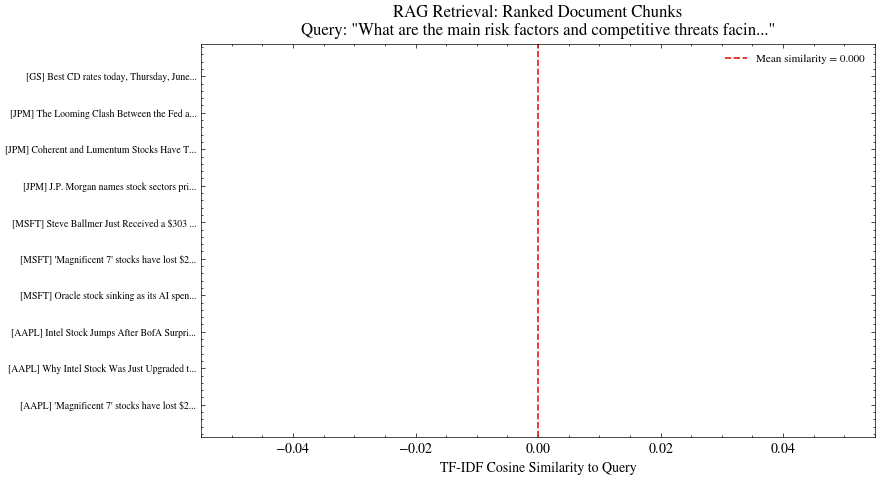

In [2]:
vectorizer = TfidfVectorizer(stop_words="english")
X = vectorizer.fit_transform([query] + chunks)
sims = cosine_similarity(X[0:1], X[1:])[0]

order = np.argsort(sims)[::-1]
sorted_sims  = sims[order]
sorted_labels = [chunk_labels[i] for i in order]

norm = plt.Normalize(vmin=sorted_sims.min(), vmax=sorted_sims.max())
bar_colors = plt.cm.RdYlGn(norm(sorted_sims))

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(range(len(sorted_sims)), sorted_sims,
        color=bar_colors, edgecolor="none")
ax.set_yticks(range(len(sorted_labels)))
ax.set_yticklabels(sorted_labels, fontsize=7)
ax.set_xlabel("TF-IDF Cosine Similarity to Query")
ax.set_title("RAG Retrieval: Ranked Document Chunks\n"
             f"Query: \"{query[:60]}...\"")
ax.invert_yaxis()
ax.axvline(sorted_sims.mean(), color="#e41a1c", linestyle="--", lw=1.2,
           label=f"Mean similarity = {sorted_sims.mean():.3f}")
ax.legend(fontsize=8)
fig.tight_layout()

out_path = pathlib.Path(
    "../../../book/chapters/04-llm-agents/figures/fig_illustration.pdf"
)
out_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out_path, bbox_inches="tight", dpi=150)
print(f"Saved to {out_path.resolve()}")
plt.show()

## Your Turn

Replace TF-IDF with a dense embedding approach: encode the query and all chunks
using `sentence-transformers` (model `"all-MiniLM-L6-v2"`) and recompute cosine
similarities. Compare the ranking to the TF-IDF result. Which method surfaces
more thematically relevant chunks? Why might dense retrieval outperform TF-IDF
for financial risk questions?

# Chapter 4 — Exercises: LLM Agents and Finance Applications

This notebook contains starter code for the exercises in Chapter 4 of *Large Language Models in Finance*.

**Exercises:**
- [B] ReAct agent for earnings call Q&A
- [I] RAG pipeline for SEC filings with ablation study
- [A] Multi-agent earnings analyst system

[Placeholder — fill in with exercise starter code when drafting the chapter]